<h1>Convolutional Neural Networks</h1>
<br>
<img src="https://miro.medium.com/max/2000/1*1TI1aGBZ4dybR6__DI9dzA.png" width="900" align="center">

<br><br>
In this lab, we will be constructing and training a "Convolutional Neural Network," aka a neural network that contains convolution kernels with learnable parameters.<br>

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.utils.data.dataloader as dataloader

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.auto import trange, tqdm

In [20]:
# The size of our mini-batches
batch_size = 512

# How many iterations of our dataset
num_epochs = 10

# Optimizer learning rate
learning_rate = 1e-4

# Where to load/save the dataset from 
data_set_root = "../../datasets"

In [21]:
# Set device to GPU_indx if GPU is avaliable
gpu_indx = 0
device = torch.device(gpu_indx if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

<h3> Create a transform for the input data </h3>
As we have seen, we often wish to perform some operations on data before we pass it through our model. Such operations could be, cropping or resizing images, affine transforms and data normalizations. Pytorch's torchvision module has a large number of such "transforms" which can be strung together sequentially using the "Compose" function. <br>

Pytorch's inbuilt datasets take a transform as an input and will apply this transform to the data before passing it to you! This makes preprocessing data really easy! We will see more about data preprocessing in a later lab!

[torchvision.transforms](https://pytorch.org/vision/0.9/transforms.html#)

In [22]:
# Prepare a composition of transforms
# transforms.Compose will perform the transforms in order
# NOTE: some transforms only take in a PIL image, others only a Tensor
# EG Resize and ToTensor take in a PIL Image, Normalize takes in a Tensor
# Refer to the documentation
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize([0.1307], [0.308])
])

# Note: ToTensor() will scale unit8 and similar type data to a float and re-scale to 0-1
# Note: We are normalizing with the dataset mean and standard deviation 

<h3> Create the training, testing and validation data</h3>
When training many machine learning systems it is best practice to have our TOTAL dataset split into three segments, the training set, testing set and validation set. Up until now we have only had a train/test set split and have used the test set to gauge the performance during training. Though for the most "unbiased" results we should really not use our test set until training is done! So if we want to evaluate our model on an "unseen" part of the dataset we need another split - the validation set. <br><br>
<b>Training set</b>   - the data we train our model on<br>
<b>Validation set</b> - the data we use to gauge model performance during training<br>
<b>Testing set</b>   - the data we use to "rate" our trained model<br>

In [23]:
# Define our MNIST Datasets
# Can also try with the CIFAR10 Dataset
# https://pytorch.org/docs/stable/torchvision/datasets.html#mnist
train_data = datasets.MNIST(data_set_root, train=True, download=True, transform=transform)
test_data = datasets.MNIST(data_set_root, train=False, download=True, transform=transform)

# We are going to split the test dataset into a train and validation set, 90%/10%
validation_split = 0.9

# Determine the number of samples for each split
n_train_examples = int(len(train_data)*validation_split)
n_valid_examples = len(train_data) - n_train_examples

# The function random_split will take our dataset and split it randomly, and give us the datasets that are the sizes we gave it
# Note: We can split it into more than two pieces!
train_data, valid_data = torch.utils.data.random_split(
    train_data, [n_train_examples, n_valid_examples],
    generator=torch.Generator().manual_seed(42)
)

# IMPORTANT TO KNOW!!!!!!!!!
# Here we pass the random_split function a manual seed, this is very important, as if we did not do this, then 
# every time we randomly split our training and validation set, we would get different splits!!!
# For example, if we saved our model and reloaded it in the future to train some more, the dataset that we now use to
# train with will undoubtedly contain datapoints that WERE in the validation set initially!!
# Our model would therefore be trained with validation and training data -- very bad!!!
# Setting the manual seed to the same value every time prevents this!

<h3> Check the lengths of all the datasets</h3>

In [24]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_data)}')

Number of training examples: 54000
Number of validation examples: 6000
Number of testing examples: 10000


<h3> Create the dataloader</h3>

In [25]:
# Create the training, Validation, and Evaluation/Test Datasets
# It is best practice to separate your data into these three Datasets
# Though, depending on your task, you may only need Training + Evaluation/Test, or maybe only a Training set
# (It also depends on how much data you have)
# https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataloader
train_loader = dataloader.DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_loader = dataloader.DataLoader(valid_data, batch_size=batch_size)
test_loader  = dataloader.DataLoader(test_data, batch_size=batch_size)

<h2> Create the LeNet5 network</h2>

[LeNet5](https://en.wikipedia.org/wiki/LeNet) is a "classic" old convolutional neural network (one of the oldest, dating back to 1998). We will be creating an implementation of it here! It uses both convolutional layers and linear layers to "learn" features of the image and perform the classification. <br>
It also uses [Max Pooling](https://computersciencewiki.org/index.php/Max-pooling_/_Pooling) to downsample the "feature maps" (the 2d hidden layers at the output of a convolutional layer, in the image at the top of the notebook, they are called "Subsampling" layers)


In [26]:
class LeNet(nn.Module):
    def __init__(self, channels_in):
        # Call the __init__ function of the parent nn.module class
        super(LeNet, self).__init__()
        # Define Convolution Layers
        # conv1 6 channels_inx5x5 kernels
        self.conv1 = nn.Conv2d(channels_in, 6, 5)
        
        # conv2 16 6x5x5 kernels
        self.conv2 = nn.Conv2d(6, 16, 5)
        
        # Define MaxPooling Layers
        # Default Stride is equal to kernel_size
        self.maxpool = nn.MaxPool2d(kernel_size=2)
        
        # Define Linear/Fully connected/ Dense Layers
        # Input to linear1 is the number of features from the previous conv - 16x5x5
        # output of linear1 is 120
        self.linear1 = nn.Linear(16*5*5, 120)
        # output of linear2 is 84
        self.linear2 = nn.Linear(120, 84)
        # output of linear3 is 10
        self.linear3 = nn.Linear(84, 10)
            
    def forward(self, x):
        # Pass input through conv layers
        # x shape is BatchSize-3-32-32
        
        out1 = F.relu(self.conv1(x))
        # out1 shape is BatchSize-6-28-28
        out1 = self.maxpool(out1)
        # out1 shape is BatchSize-6-14-14

        out2 = F.relu(self.conv2(out1))
        # out2 shape is BatchSize-16-10-10
        out2 = self.maxpool(out2)
        # out2 shape is BatchSize-16-5-5

        # Flatten out2 to shape BatchSize-16x5x5
        out2 = out2.view(out2.shape[0], -1)
        
        out3 = F.relu(self.linear1(out2))
        # out3 shape is BatchSize-120
        out4 = F.relu(self.linear2(out3))
        # out4 shape is BatchSize-84
        out5 = F.relu(self.linear3(out4))
        # out5 shape is BatchSize-10
        
        return out5

<h3> Create our model and view the ouput! </h3>

In [27]:
# Create a dataloader iterable object
dataiter = iter(test_loader)
# Sample from the itterable object
test_images, test_labels = next(iter(test_loader))

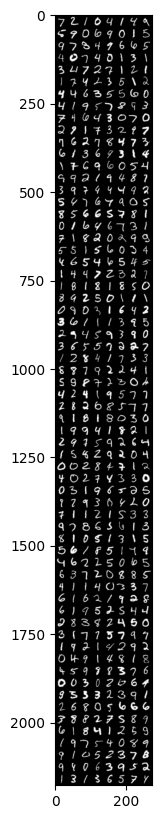

In [ ]:
# Let's visualise an entire batch of images!
plt.figure(figsize = (10,10))
out = torchvision.utils.make_grid(test_images, 8, normalize=True)
plt.imshow(out.numpy().transpose((1, 2, 0)))

In [29]:
# Create an instance of our network and put it on our device
# Set channels_in to the number of channels of the dataset images (1 channel for MNIST)
model = LeNet(channels_in=1).to(device)

# View the network
# Note that the layer order is simply the order in which we defined them, NOT the order of the forward pass
print(model)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): Linear(in_features=400, out_features=120, bias=True)
  (linear2): Linear(in_features=120, out_features=84, bias=True)
  (linear3): Linear(in_features=84, out_features=10, bias=True)
)


In [30]:
# Pass image through the network
out = model(test_images.to(device))

# Check output
out.shape

torch.Size([512, 10])

<h3> Set up the optimizer </h3>

In [31]:
# Pass our network parameters to an Adam optimiser and set our lr as the learning_rate
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

In [32]:
# Define a Cross Entropy Loss
loss_fun = nn.CrossEntropyLoss()

# Define the training process

In [33]:
# This function should perform a single training epoch using our training data
def train(model, optimizer, loader, device, loss_fun, loss_logger):
    
    # Set Network in train mode
    model.train()
    for i, (x, y) in enumerate(tqdm(loader, leave=False, desc="Training")):
        # Forward pass of image through network and get output
        fx = model(x.to(device))
        
        # Calculate loss using loss function
        loss = loss_fun(fx, y.to(device))

        # Zero gradients
        optimizer.zero_grad()
        
        # Backpropagate gradients
        loss.backward()
        
        # Do a single optimization step
        optimizer.step()
        
        # Log the loss for plotting
        loss_logger.append(loss.item())
        
    # Return the avaerage loss and acc from the epoch as well as the logger array       
    return model, optimizer, loss_logger

# Define the testing process

In [34]:
# This function should perform a single evaluation epoch, it WILL NOT be used to train our model
def evaluate(model, device, loader):
    
    # Initialise counter
    epoch_acc = 0
    
    # Set network in evaluation mode
    # Layers like Dropout will be disabled
    # Layers like Batchnorm will stop calculating running mean and standard deviation
    # and use current stored values (More on these layer types soon!)
    model.eval()
    
    with torch.no_grad():
        for i, (x, y) in enumerate(tqdm(loader, leave=False, desc="Evaluating")):
            # Forward pass of image through network
            fx = model(x.to(device))
            
            # Log the cumulative sum of the acc
            epoch_acc += (fx.argmax(1) == y.to(device)).sum().item()
            
    # Return the accuracy from the epoch
    return epoch_acc / len(loader.dataset)

# The training process

In [35]:
training_loss_logger = []
validation_acc_logger = []
training_acc_logger = []

In [36]:
# This cell implements our training loop
for epoch in trange(num_epochs, leave=False, desc="Epoch"):
    
    # Call the training function and pass the training dataloader, etc
    model, optimizer, training_loss_logger = train(model, optimizer, train_loader, device, loss_fun, training_loss_logger)
    
    # Call the evaluate function and pass the dataloader for both validation and training
    train_acc = evaluate(model, device, train_loader)
    valid_acc = evaluate(model, device, valid_loader)
    
    # Log the train and validation accuracies
    validation_acc_logger.append(valid_acc)
    training_acc_logger.append(train_acc)
    
print("Training Complete")

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/106 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/106 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

Training:   0%|          | 0/106 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

Training:   0%|          | 0/106 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/106 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

Training Complete


Text(0.5, 1.0, 'LeNet Training Loss')

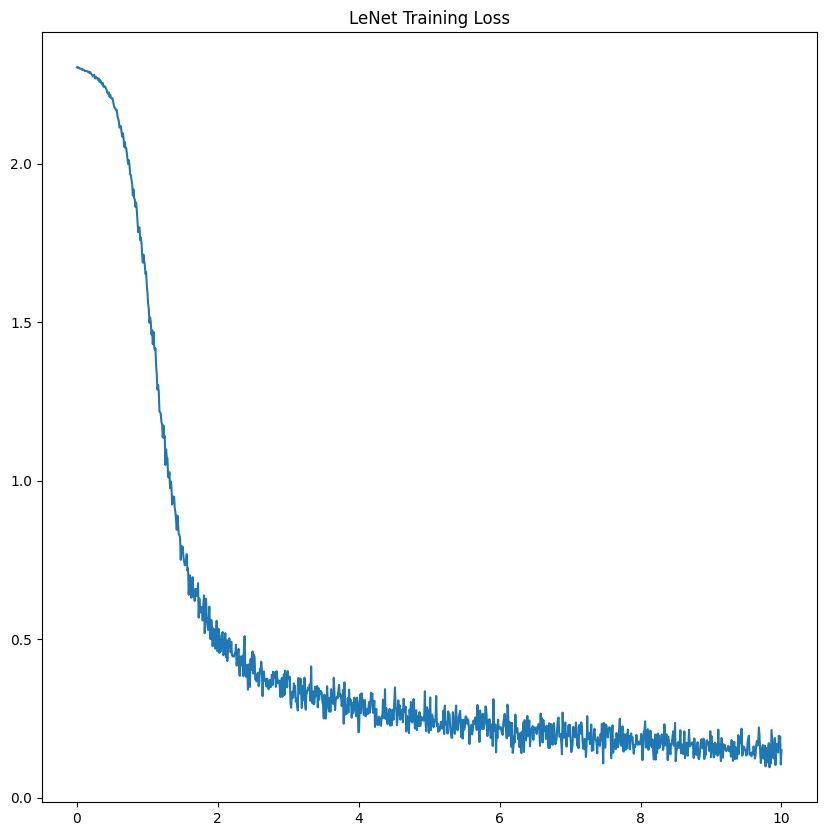

In [37]:
plt.figure(figsize = (10,10))
train_x = np.linspace(0, num_epochs, len(training_loss_logger))
plt.plot(train_x, training_loss_logger)
plt.title("LeNet Training Loss")

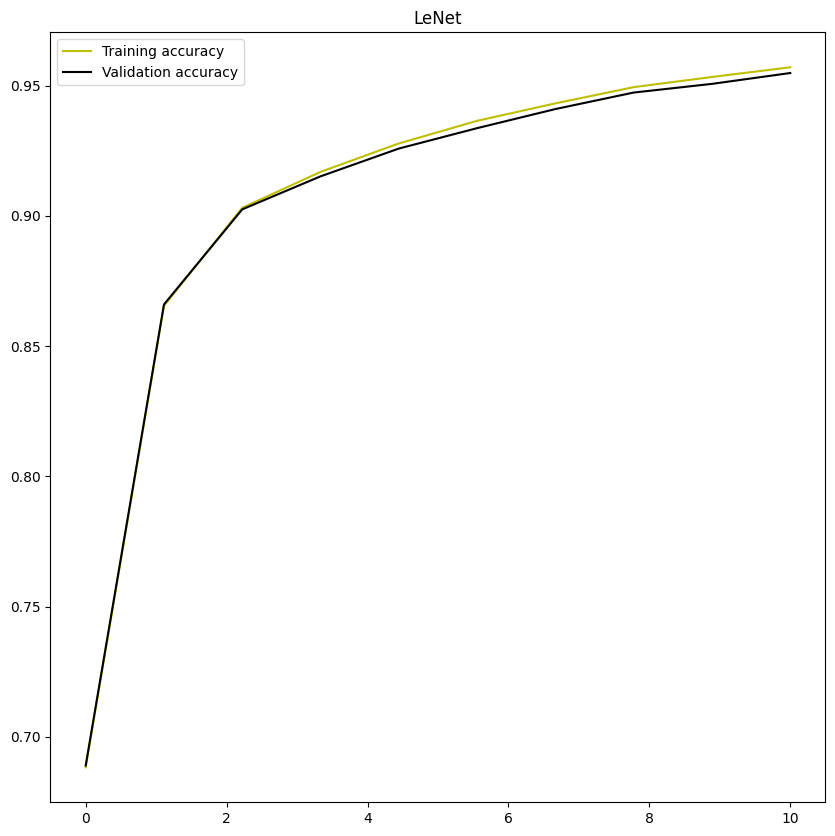

In [38]:
plt.figure(figsize = (10,10))
train_x = np.linspace(0, num_epochs, len(training_acc_logger))
plt.plot(train_x, training_acc_logger, c = "y")
valid_x = np.linspace(0, num_epochs, len(validation_acc_logger))
plt.plot(valid_x, validation_acc_logger, c = "k")

plt.title("LeNet")
plt.legend(["Training accuracy", "Validation accuracy"])

# Evaluate

In [39]:
# Call the evaluate function and pass the evaluation/test dataloader etc
test_acc = evaluate(model, device, test_loader)
print("The total test accuracy is: %.2f%%" %(test_acc*100))

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

The total test accuracy is: 95.88%


Predicted Values
 [7, 2, 1, 0, 4, 1, 4, 9]
True Values
 [7, 2, 1, 0, 4, 1, 4, 9]


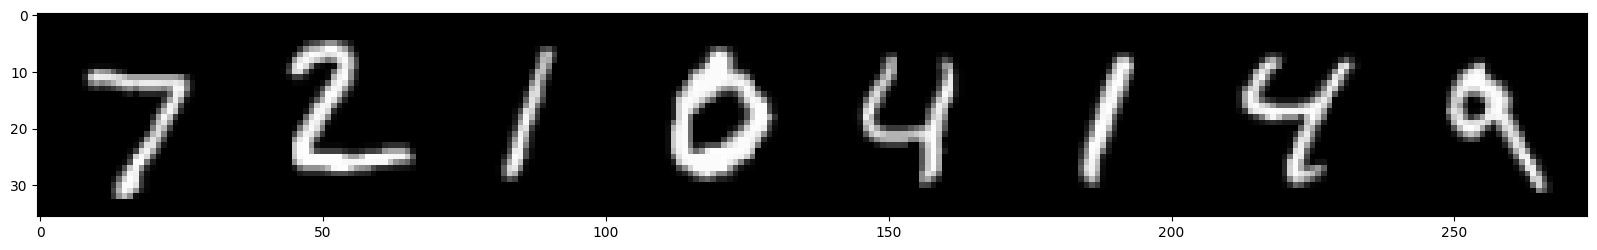

In [41]:
# Let's visualise the prediction for a few test images!

images_to_test = test_images[:8]
with torch.no_grad():
    # Forward pass of the images to test
    fx = model(images_to_test.to(device))
    
    # Get the class indices
    class_pred = fx.argmax(1)
    
plt.figure(figsize = (20,10))
out = torchvision.utils.make_grid(images_to_test, 8, normalize=True)
plt.imshow(out.numpy().transpose((1, 2, 0)))

print("Predicted Values\n", list(class_pred.cpu().numpy()))
print("True Values\n", list(test_labels[:8].numpy()))